#### ライブラリのimport

In [14]:
import pandas as pd
from google.cloud import bigquery
from google.cloud import storage
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib

#### データ取得

In [2]:
# BigQueryクライアントを作成する
client = bigquery.Client()

# 取得するデータの範囲を指定する
years = [2023, 2024, 2025]
place_ids = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10"]

# クエリを作成する
query = ""
for year in years:
    for place_id in place_ids:
        if year != years[0] or place_id != "01":
            query += " UNION ALL "
        query += f"""
        SELECT *
        FROM `keiba-ai-487108.datalake.race_result_{year}_{place_id}`
        """

# クエリを実行してデータを取得する
df = client.query(query).to_dataframe()

/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


#### 前処理

In [3]:
# 馬名
if '馬' in df.columns:
    le_horse = LabelEncoder()
    df['馬名カテゴリ'] = le_horse.fit_transform(df['馬'])

# 騎手
if '騎手' in df.columns:
    le_jockey = LabelEncoder()
    df['騎手カテゴリ'] = le_jockey.fit_transform(df['騎手'])

In [4]:
# 単勝ラベル（1着予測用）を作成
df['単勝ラベル'] = (df['着順'] == "1").astype(int)

In [25]:
# 馬ごとの連対率を計算
def calc_ren_tai_rate(df, group_col):
    grouped = df.groupby(group_col)
    total = grouped.size()
    win = grouped.apply(lambda x: (x['着順'] == "1").sum())
    place2 = grouped.apply(lambda x: (x['着順'] == "2").sum())
    rentai = (win + place2) / total
    result = pd.DataFrame({
        f'{group_col}_出走数': total,
        f'{group_col}_勝利数': win,
        f'{group_col}_2着数': place2,
        f'{group_col}_連対率': rentai
    })
    return result.reset_index()

# 馬ごと
horse_rentai_df = calc_ren_tai_rate(df, '馬')
horse_rentai_df = horse_rentai_df.sort_values(f'馬_連対率', ascending=False)

# 騎手ごと
jockey_rentai_df = calc_ren_tai_rate(df, '騎手')
jockey_rentai_df = jockey_rentai_df.sort_values(f'騎手_連対率', ascending=False)

/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipykernel_77726/664070459.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win = grouped.apply(lambda x: (x['着順'] == "1").sum())
/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipykernel_77726/664070459.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  place2 = grouped.apply(lambda x: (x['着順'] == "2").sum())
/var/folders/sd/pm6qxyz13v507yx_8zv3j1pr0000gn/T/ipyker

In [56]:
# 馬: 出走数5以上の馬のみ連対率を使う
horse_rentai_feat = horse_rentai_df.copy()
horse_rentai_feat.loc[horse_rentai_feat['馬_出走数'] < 3, '馬_連対率'] = np.nan  # 3未満はNaN
horse_rentai_feat.fillna(horse_rentai_feat['馬_連対率'].mean(), inplace=True)  # NaNを平均値で埋める

# 騎手: 出走数5以上の騎手のみ連対率を使う
jockey_rentai_feat = jockey_rentai_df.copy()
jockey_rentai_feat.loc[jockey_rentai_feat['騎手_出走数'] < 3, '騎手_連対率'] = np.nan  # 3未満はNaN
jockey_rentai_feat.fillna(jockey_rentai_feat['騎手_連対率'].mean(), inplace=True)  # NaNを平均値で埋める

In [57]:
# 元データにマージ
# まず馬の連対率
feature_df = df.merge(horse_rentai_feat[['馬', '馬_連対率']], on='馬', how='left')

# 騎手の連対率
feature_df = feature_df.merge(jockey_rentai_df[['騎手', '騎手_連対率']], on='騎手', how='left')

In [60]:
# 推論時ように、馬_連対率と騎手_連対率をBQに保存しておく

# 馬連帯率をBQに保存
table_id = f"keiba-ai-487108.dwh.horse_rentai_win_rate"
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND,
)
job = client.load_table_from_dataframe(horse_rentai_df, table_id, job_config=job_config)
job.result()  # Wait for the job to complete
print(f"Uploaded {len(horse_rentai_df)} rows to {table_id}")

# 騎手連帯率をBQに保存
table_id = f"keiba-ai-487108.dwh.jockey_rentai_win_rate"
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND,
)
job = client.load_table_from_dataframe(jockey_rentai_df, table_id, job_config=job_config)
job.result()  # Wait for the job to complete
print(f"Uploaded {len(jockey_rentai_df)} rows to {table_id}")


/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 21752 rows to keiba-ai-487108.dwh.horse_rentai_win_rate


/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 271 rows to keiba-ai-487108.dwh.jockey_rentai_win_rate


In [51]:
horse_rentai_df

,馬,馬_出走数,馬_勝利数,馬_2着数,馬_連対率
1078,アロハ,1,0,1,1.0
20760,レモンポップ,4,4,0,1.0
9787,タイセイエムロード,1,1,0,1.0
17128,マリリンバローズ,1,0,1,1.0
5171,グランアプロウソ,2,1,1,1.0
...,...,...,...,...,...
9003,スマートウィザード,5,0,0,0.0
9004,スマートエクシード,3,0,0,0.0
9005,スマートエステラ,5,0,0,0.0
9006,スマートエラン,1,0,0,0.0


In [ ]:

# BigQueryにアップロード
client = bigquery.Client()
table_id = f"keiba-ai-487108.datalake.race_result_{year}_{place_id}"
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND,
)
job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
job.result()  # Wait for the job to complete
print(f"Uploaded {len(df)} rows to {table_id}")

In [41]:
horse_rentai_dict

{'アロハ': 1.0,
 'レモンポップ': 1.0,
 'タイセイエムロード': 1.0,
 'マリリンバローズ': 1.0,
 'グランアプロウソ': 1.0,
 'インビジブルセルフ': 1.0,
 'リュウカルネ': 1.0,
 'シャドウマスター': 1.0,
 'タイセイパルス': 1.0,
 'グランドプラージュ': 1.0,
 'シニャンガ': 1.0,
 'グリオンヴール': 1.0,
 'アッカン': 1.0,
 'タイセイラヴィータ': 1.0,
 'デルマリシリ': 1.0,
 'リュクスパトロール': 1.0,
 'タイニーワンダー': 1.0,
 'タイムレスキス': 1.0,
 'シックスリングス': 1.0,
 'システマソラー': 1.0,
 'ノーザンタイタン': 1.0,
 'アストロレガシー': 1.0,
 'フェルミアーク': 1.0,
 'シオンダンサー': 1.0,
 'グレースジェンヌ': 1.0,
 'タカスタカスタカス': 1.0,
 'ノーブルサヴェージ': 1.0,
 'ウィクトルウェルス': 1.0,
 'タガノシルフィー': 1.0,
 'シャンパンポップ': 1.0,
 'グラシリティ': 1.0,
 'ダノンバーボン': 1.0,
 'プロメサアルムンド': 1.0,
 'アビル': 1.0,
 'マテンロウゲイル': 1.0,
 'ショウナンマルチ': 1.0,
 'イベントホライゾン': 1.0,
 'クレパスキュラー': 1.0,
 'リスレジャンデール': 1.0,
 'マテンロウネイビー': 1.0,
 'ショウナンハヤナミ': 1.0,
 'イモータリス': 1.0,
 'フィロステファニ': 1.0,
 'フィンガー': 1.0,
 'ソラネルマン': 1.0,
 'ショウナンアストラ': 1.0,
 'ソルオーブ': 1.0,
 'モートンアイランド': 1.0,
 'ソルチェリア': 1.0,
 'ショウグンマサムネ': 1.0,
 'モンローウォーク': 1.0,
 'ソングライン': 1.0,
 'オーサムリザルト': 1.0,
 'トシッキー': 1.0,
 'マメタンク': 1.0,
 'シュネルアンジュ': 1.0,
 'フィールドノート': 1.0,
 'アドマイヤシュラ

In [61]:
# 使う特徴量を選択
features_emb = [
    'オッズ', '体重', '斤量', '人気', '馬番', '体重変化', '齢',
    '馬_連対率', '騎手_連対率'
 ]

for feat in features_emb:
    feature_df[feat] = pd.to_numeric(feature_df[feat], errors='coerce')

X_emb = feature_df[features_emb].astype(float)
y = feature_df['単勝ラベル']

In [62]:
# 学習・評価
X_train, X_test, y_train, y_test = train_test_split(X_emb, y, test_size=0.2, random_state=42)
model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8221, number of negative: 105919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874
[LightGBM] [Info] Number of data points in the train set: 114140, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [63]:
# 日本語フォントを指定
matplotlib.rcParams['font.family'] = 'Hiragino Sans'  # macOS標準日本語フォント


# 文字化け対策（マイナス記号など）
matplotlib.rcParams['axes.unicode_minus'] = False

AUC: 0.870
F1: 0.329
Accuracy: 0.743
Precision: 0.205
Recall: 0.834
--- Confusion Matrix ---
[[19394  6987]
 [  358  1797]]
--- Classification Report ---
              precision    recall  f1-score   support

           0      0.982     0.735     0.841     26381
           1      0.205     0.834     0.329      2155

    accuracy                          0.743     28536
   macro avg      0.593     0.785     0.585     28536
weighted avg      0.923     0.743     0.802     28536



/Users/naozumi/Desktop/WorkSpace/keiba_ai_app/app/keiba_science/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


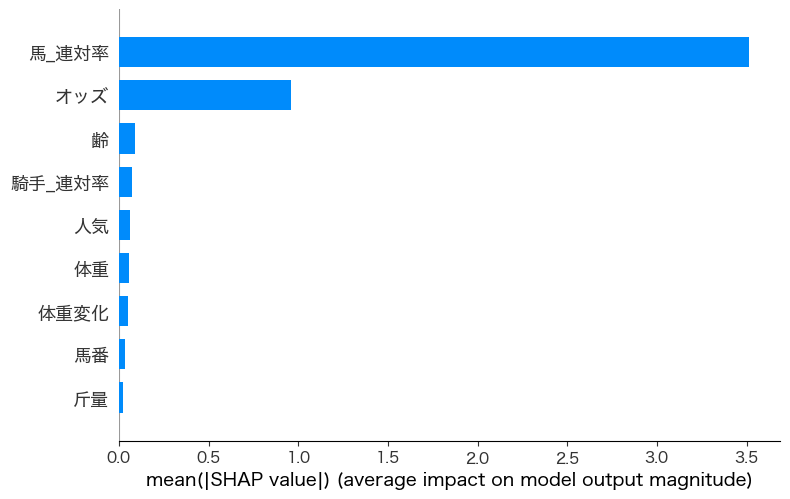

In [64]:
pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, pred_proba)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'AUC: {auc:.3f}')
print(f'F1: {f1:.3f}')
print(f'Accuracy: {acc:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, y_pred))
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, digits=3))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [67]:
# しきい値を0.9にして評価
threshold = 0.9
y_pred_th07 = (pred_proba > threshold).astype(int)
print(f'--- threshold={threshold} ---')
print('Precision:', precision_score(y_test, y_pred_th07))
print('Recall:', recall_score(y_test, y_pred_th07))
print('F1:', f1_score(y_test, y_pred_th07))
print(confusion_matrix(y_test, y_pred_th07))

--- threshold=0.9 ---
Precision: 0.5338983050847458
Recall: 0.11693735498839908
F1: 0.19185382565664255
[[26161   220]
 [ 1903   252]]


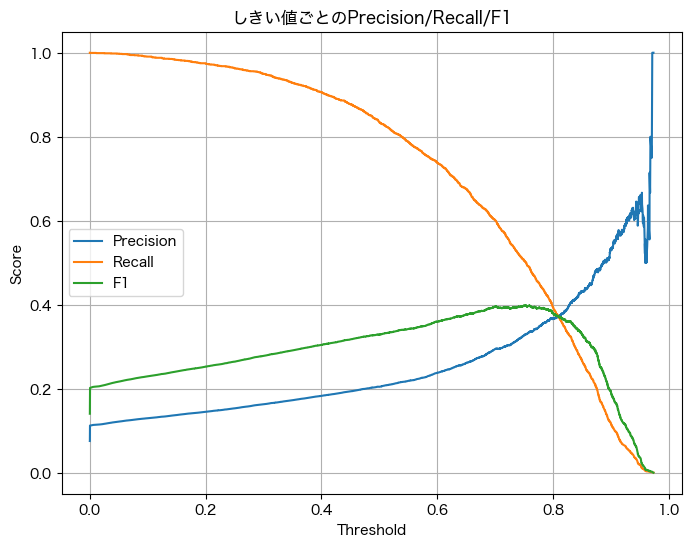

In [68]:
# しきい値ごとのprecision/recall/F1を可視化
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)
f1s = [f1_score(y_test, (pred_proba > t).astype(int)) for t in thresholds]

plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('しきい値ごとのPrecision/Recall/F1')
plt.legend()
plt.grid(True)
plt.show()

In [69]:
# ...existing code...

# ROIシミュレーション（しきい値を超えたらbet、的中ならオッズ×賭け金を回収）
bet_amount = 100  # 1レースあたりのbet金額
threshold = 0.9   # 予測確率のしきい値

bets = pred_proba > threshold
num_bets = bets.sum()
num_hits = ((y_test == 1) & bets).sum()

# 的中した馬のオッズを取得
odds_hit = X_test.loc[(y_test == 1) & bets, 'オッズ']

# 払戻金合計
total_return = (odds_hit * bet_amount).sum()
# 投資金額合計
total_bet = num_bets * bet_amount
# ROI計算
roi = total_return / total_bet if total_bet > 0 else 0

print(f'ベット回数: {num_bets}')
print(f'的中回数: {num_hits}')
print(f'投資金額: {total_bet}')
print(f'払戻金額: {total_return:.0f}')
print(f'ROI: {roi:.3f}')

ベット回数: 472
的中回数: 252
投資金額: 47200
払戻金額: 43470
ROI: 0.921


In [72]:
X_test

,オッズ,体重,斤量,人気,馬番,体重変化,齢,馬_連対率,騎手_連対率
8033,77.4,514.0,58.0,11.0,1.0,-10.0,7.0,0.000000,0.100219
103416,25.7,438.0,51.0,7.0,7.0,2.0,3.0,0.000000,0.057085
34412,2.8,514.0,55.0,1.0,3.0,0.0,2.0,0.000000,0.170455
3427,214.3,462.0,51.0,15.0,7.0,0.0,3.0,0.000000,0.040258
133459,5.8,542.0,55.0,3.0,5.0,6.0,3.0,0.250000,0.104561
...,...,...,...,...,...,...,...,...,...
84949,11.2,494.0,57.0,5.0,15.0,-2.0,3.0,0.000000,0.185145
79115,50.8,454.0,53.0,9.0,4.0,0.0,2.0,0.714286,0.167180
93161,27.7,496.0,56.0,8.0,2.0,2.0,4.0,0.400000,0.118788
47829,7.3,506.0,56.0,4.0,1.0,-6.0,2.0,0.000000,0.126942


In [73]:
# モデルをGCSに保存
model.booster_.save_model('lgbm_model.txt')
storage_client = storage.Client()
bucket_name = 'keiba_ai_models'
bucket = storage_client.bucket(bucket_name)
blob = bucket.blob('lgbm_model.txt')
blob.upload_from_filename('lgbm_model.txt')
print('モデルをGCSに保存しました。')

モデルをGCSに保存しました。
